# Task 6: Housing price predictor

Predicting the median house value of a California district using a Random Forest.
Steps: look at the data, split it, scale the features, train a decision tree and a random forest, compare them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Load the data

In [2]:
df = pd.read_csv("data/housing.csv")
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Only `total_bedrooms` has missing values (207 rows). I will fill them with the median.

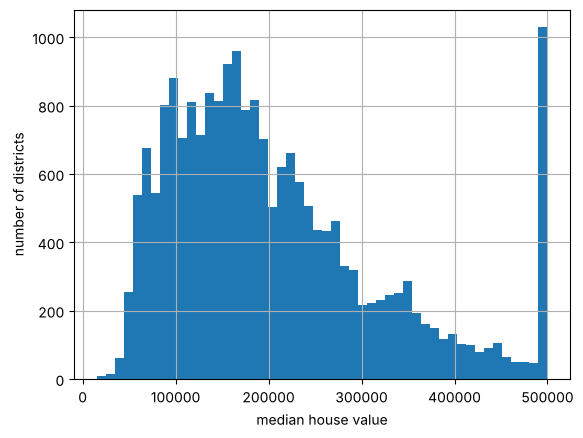

In [5]:
df["median_house_value"].hist(bins=50)
plt.xlabel("median house value")
plt.ylabel("number of districts")
plt.show()

There is a spike at 500,000. The prices in this dataset are capped there, so the model can never predict above it.

In [6]:
df.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

`median_income` has the highest correlation with the price (0.69).

## 2. Split the data

In [7]:
X = df.drop(columns="median_house_value")
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(16512, 9) (4128, 9)


## 3. Preprocessing with feature scaling

- numeric columns: fill missing values with the median, then StandardScaler
- `ocean_proximity` is text, so I use one-hot encoding

Everything goes inside a Pipeline so the same steps are applied to the test data and to new data later (API and dashboard).

In [8]:
num_cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
            "total_bedrooms", "population", "households", "median_income"]
cat_cols = ["ocean_proximity"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("fill", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(), cat_cols),
])

## 4. Train and compare models

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Decision Tree (max_depth=10)": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

results = []
for name, m in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", m)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append([name,
                    np.sqrt(mean_squared_error(y_test, pred)),
                    mean_absolute_error(y_test, pred),
                    r2_score(y_test, pred)])

pd.DataFrame(results, columns=["model", "RMSE", "MAE", "R2"]).round(3)

,model,RMSE,MAE,R2
0,Linear Regression,70059.193,50670.489,0.625
1,Decision Tree,69175.769,43604.014,0.635
2,Decision Tree (max_depth=10),61279.694,40556.376,0.713
3,Random Forest,48941.700,31628.407,0.817


The random forest is clearly the best (R2 0.82). The normal decision tree overfits, because it learns the training data too well.
Limiting the depth helps a bit, but averaging 100 trees in a forest works much better.

## 5. Final model (Random Forest)

In [10]:
final_model = Pipeline([("preprocess", preprocess), ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
final_model.fit(X_train, y_train)
pred = final_model.predict(X_test)

print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred))))
print("MAE :", round(mean_absolute_error(y_test, pred)))
print("R2  :", round(r2_score(y_test, pred), 3))

RMSE: 48942
MAE : 31628
R2  : 0.817


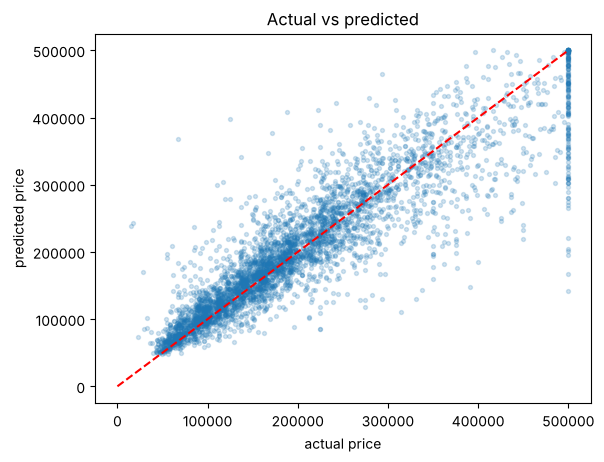

In [11]:
plt.scatter(y_test, pred, alpha=0.2, s=8)
plt.plot([0, 500000], [0, 500000], "r--")
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("Actual vs predicted")
plt.show()

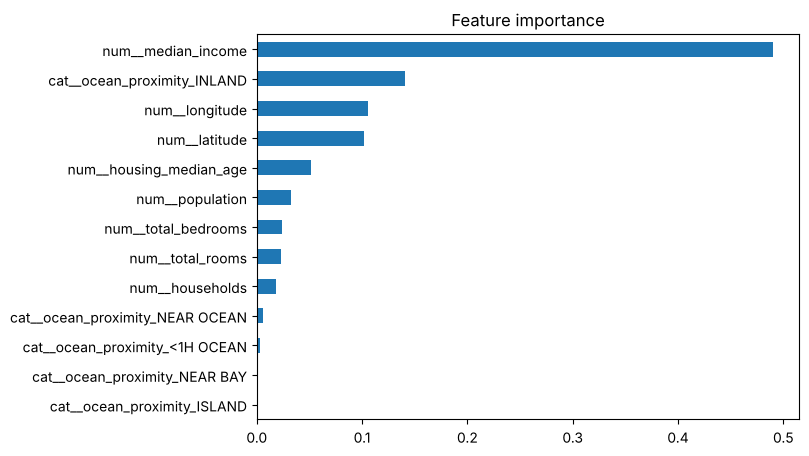

In [12]:
names = final_model.named_steps["preprocess"].get_feature_names_out()
importance = pd.Series(final_model.named_steps["model"].feature_importances_, index=names).sort_values()
importance.plot.barh(figsize=(7, 5))
plt.title("Feature importance")
plt.show()

Income is the most important feature by far, then location (inland, longitude, latitude).

## 6. Save the model (used in task 4 and 5)

In [13]:
joblib.dump(final_model, "model/housing_model.joblib", compress=3)

# quick check that the saved model works on a new house
saved = joblib.load("model/housing_model.joblib")
house = pd.DataFrame([{"longitude": -122.23, "latitude": 37.88, "housing_median_age": 41, "total_rooms": 880,
                       "total_bedrooms": 129, "population": 322, "households": 126,
                       "median_income": 8.3252, "ocean_proximity": "NEAR BAY"}])
print(saved.predict(house))

[431942.36]
